# **Project: English Accent Classification**
Authors:
- Gael **Sustaita**
- Benjamin **Muñiz**
- Victor **Hermosillo**

Course: Language Processing

Professor: Dr. Nigel **Ward**

## 1. **Project Overview**

### **Project Idea**
Our system is a machine learning pipeline that listens to English speech and figures out if the speaker has an American, British, Australian, or Indian accent.

### **Problem Statement**

Accents are a key part of human identity, but they can sometimes present challenges in media production or automated speech recognition. Before we can "modify" an accent, we must first be able to identify what makes an accent unique using quantifiable data.

### **Project Objectives**

- Process raw audio clips to ensure consistency by adjusting the sample rate, removing silence, and standardizing all clips to a fixed length of 3 seconds.
- Implement a "Dual-Path" feature extraction strategy comparing handcrafted acoustic features (MFCCs, pitch, energy) against high-dimensional neural embeddings (WavLM).
- Train classification models, including Logistic Regression and SVM, to produce the final accent prediction.
- Measure system performance using standard stats (Accuracy, Precision, Recall, and F1-Scores) and visualize confusion matrices.

## 2. Libraries used

In [27]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import WavLMModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from dotenv import load_dotenv

## 3. Load datasets

First, we define the global constants that will govern our audio processing pipeline. We also establish a mapping dictionary to cleanly convert Mozilla's long, descriptive accent names into simple, readable labels for our final visualizations.

In [28]:
# Audio Configuration
TARGET_SR = 16000
AUDIO_DURATION = 3 
FIXED_LENGTH = TARGET_SR * AUDIO_DURATION 

# File Paths (Adjust to your local setup)
AUDIO_FOLDER = "datasets/en/clips"
TRAIN_TSV = "datasets/en/train.tsv"
TEST_TSV = "datasets/en/test.tsv"

# Accent Mapping
ACCENT_MAPPING = {
    "United States English": "American",
    "England English": "British",
    "Australian English": "Australian",
    "India and South Asia (India, Pakistan, Sri Lanka)": "Indian"
}

# Sample counts for balancing
SAMPLES_TRAIN = 1000 
SAMPLES_TEST = 200

df = pd.read_csv(TRAIN_TSV, sep='\t')

print("Exact names of the most common accents:")
print(df['accents'].value_counts().head(10))

Exact names of the most common accents:
accents
United States English                                 287940
England English                                        90558
India and South Asia (India, Pakistan, Sri Lanka)      82898
Canadian English                                       58982
Non native speaker|German English                      52152
Australian English                                     35336
Southern African (South Africa, Zimbabwe, Namibia)     22304
Scottish English                                       13441
Northern Irish                                         10358
New Zealand English                                     6152
Name: count, dtype: int64


## 4: Processing & Loading Functions

In [29]:
def get_balanced_metadata(tsv_path, samples_per_accent):
    """Filters and balances the Mozilla metadata table."""
    df = pd.read_csv(tsv_path, sep='\t')
    df = df[df['accents'].isin(ACCENT_MAPPING.keys())]
    balanced_frames = []
    for long_name, short_name in ACCENT_MAPPING.items():
        subset = df[df['accents'] == long_name].head(samples_per_accent).copy()
        subset['clean_label'] = short_name
        balanced_frames.append(subset)
    return pd.concat(balanced_frames, ignore_index=True)

def preprocess_audio(file_path):
    """Normalizes, trims, and standardizes duration to exactly 3 seconds."""
    audio, _ = librosa.load(file_path, sr=TARGET_SR)
    audio = audio / (np.max(np.abs(audio)) + 1e-8) # Volume normalization
    audio, _ = librosa.effects.trim(audio, top_db=30) # Silence trimming
    if len(audio) < FIXED_LENGTH:
        audio = np.pad(audio, (0, FIXED_LENGTH - len(audio)))
    else:
        audio = audio[:FIXED_LENGTH]
    return audio

def build_dataset(metadata_df):
    """Loads the physical audio files based on the filtered metadata table."""
    X, y = [], []
    for _, row in metadata_df.iterrows():
        path = os.path.join(AUDIO_FOLDER, row['path'])
        try:
            X.append(preprocess_audio(path))
            y.append(row['clean_label'])
        except Exception as e:
            continue
    return np.array(X), np.array(y)

## 5: Execution of Loading (Train vs Test)

In [30]:
print("Loading Training Set...")
train_meta = get_balanced_metadata(TRAIN_TSV, SAMPLES_TRAIN)
X_train_raw, y_train = build_dataset(train_meta)

print("Loading Official Test Set...")
test_meta = get_balanced_metadata(TEST_TSV, SAMPLES_TEST)
X_test_raw, y_test = build_dataset(test_meta)

print(f"Loading complete. Train size: {len(y_train)} | Test size: {len(y_test)}")

Loading Training Set...
Loading Official Test Set...
Loading complete. Train size: 4000 | Test size: 696


## 6: Acoustic Feature Extraction

In [31]:
def extract_acoustic_features(audio_arrays):
    features = []
    for audio in audio_arrays:
        mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=TARGET_SR, n_mfcc=40), axis=1)
        zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
        energy = np.mean(audio**2)
        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=TARGET_SR))
        features.append(np.concatenate([mfcc, [zcr, energy, centroid]]))
    return np.array(features)

X_train_acc = extract_acoustic_features(X_train_raw)
X_test_acc = extract_acoustic_features(X_test_raw)

In [32]:
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
wavlm_model = WavLMModel.from_pretrained("microsoft/wavlm-base", token=hf_token)
wavlm_model.eval()

def extract_neural_embeddings(audio_arrays):
    embeddings = []
    with torch.no_grad():
        for i, audio in enumerate(audio_arrays):
            input_values = torch.tensor(audio).unsqueeze(0).float()
            outputs = wavlm_model(input_values)
            embeddings.append(outputs.last_hidden_state.mean(dim=1).squeeze().numpy())
            if (i+1) % 100 == 0: print(f"Processed {i+1} embeddings...")
    return np.array(embeddings)

X_train_neu = extract_neural_embeddings(X_train_raw)
X_test_neu = extract_neural_embeddings(X_test_raw)

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 39571.92it/s]


Processed 100 embeddings...
Processed 200 embeddings...
Processed 300 embeddings...
Processed 400 embeddings...
Processed 500 embeddings...
Processed 600 embeddings...
Processed 700 embeddings...
Processed 800 embeddings...
Processed 900 embeddings...
Processed 1000 embeddings...
Processed 1100 embeddings...
Processed 1200 embeddings...
Processed 1300 embeddings...
Processed 1400 embeddings...
Processed 1500 embeddings...
Processed 1600 embeddings...
Processed 1700 embeddings...
Processed 1800 embeddings...
Processed 1900 embeddings...
Processed 2000 embeddings...
Processed 2100 embeddings...
Processed 2200 embeddings...
Processed 2300 embeddings...
Processed 2400 embeddings...
Processed 2500 embeddings...
Processed 2600 embeddings...
Processed 2700 embeddings...
Processed 2800 embeddings...
Processed 2900 embeddings...
Processed 3000 embeddings...
Processed 3100 embeddings...
Processed 3200 embeddings...
Processed 3300 embeddings...
Processed 3400 embeddings...
Processed 3500 embeddin


Evaluando y guardando modelos...

--- Path 1: Acoustic Features (MFCC) ---
Accuracy: 0.3578
              precision    recall  f1-score   support

    American       0.37      0.44      0.40       200
  Australian       0.21      0.29      0.24        96
     British       0.34      0.23      0.27       200
      Indian       0.46      0.43      0.45       200

    accuracy                           0.36       696
   macro avg       0.34      0.35      0.34       696
weighted avg       0.37      0.36      0.36       696



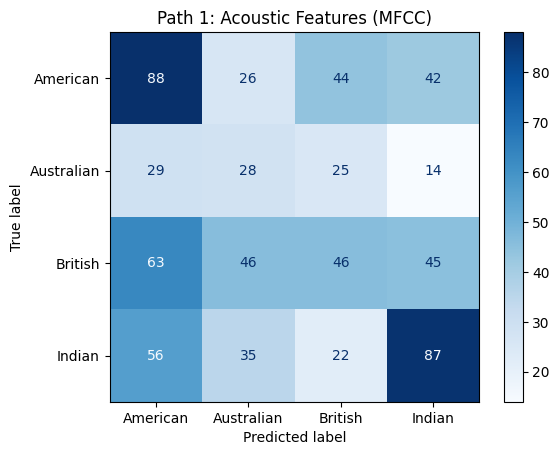


--- Path 2: Neural Embeddings (WavLM) ---
Accuracy: 0.6710
              precision    recall  f1-score   support

    American       0.72      0.68      0.70       200
  Australian       0.56      0.61      0.58        96
     British       0.69      0.53      0.59       200
      Indian       0.68      0.83      0.75       200

    accuracy                           0.67       696
   macro avg       0.66      0.66      0.66       696
weighted avg       0.67      0.67      0.67       696



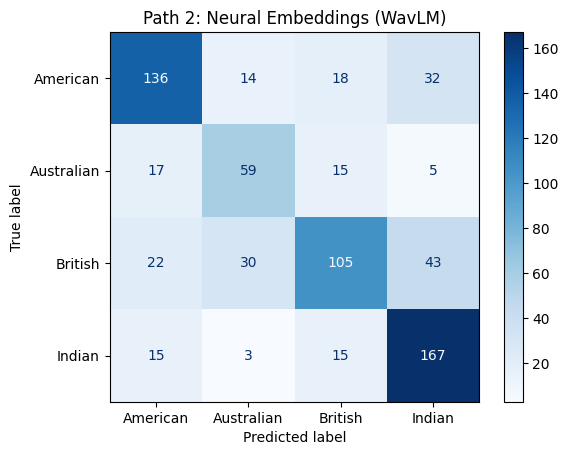

In [33]:
def run_evaluation(X_train, X_test, y_train, y_test, title):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train_s, y_train)
    
    preds = model.predict(X_test_s)
    print(f"\n--- {title} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds))
    
    ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap='Blues')
    plt.title(title)
    plt.show()
    
    # CRÍTICO: Devolver el scaler y el modelo entrenado
    return scaler, model

# --- EJECUCIÓN Y GUARDADO EN MEMORIA GLOBAL ---
print("\nEvaluando y guardando modelos...")

# Ahora sí, guardamos el resultado de la función en las variables globales
scaler_mfcc, svm_mfcc = run_evaluation(
    X_train_acc, X_test_acc, y_train, y_test, "Path 1: Acoustic Features (MFCC)"
)

scaler_wavlm, svm_wavlm = run_evaluation(
    X_train_neu, X_test_neu, y_train, y_test, "Path 2: Neural Embeddings (WavLM)"
)

## 15. Inference: Predicting New Audio Files
This function allows us to take any external audio file and pass it through our complete pipeline. It handles preprocessing, feature extraction, scaling (using our fitted scaler), and final prediction. 

**Note:** For this to work, you must use the `scaler` and `model` variables that were trained in the previous steps.

In [35]:
def predict_accent(file_path, path_type="acoustic"):
    """
    Takes a path to a new audio file and returns the predicted accent.
    path_type: "acoustic" for MFCC path, "neural" for WavLM path.
    """
    # 1. Preprocess the new audio (same as training)
    # We use the function defined in Block 2
    audio_processed = preprocess_audio(file_path)
    
    if path_type == "acoustic":
        # 2a. Extract Acoustic Features
        features = extract_acoustic_features([audio_processed])
        # Use the scaler from the acoustic training
        features_scaled = scaler_mfcc.transform(features)
        prediction = svm_mfcc.predict(features_scaled)
        
    else:
        # 2b. Extract Neural Embeddings
        features = extract_neural_embeddings([audio_processed])
        # Use the scaler from the neural training
        features_scaled = scaler_wavlm.transform(features)
        prediction = svm_wavlm.predict(features_scaled)
    
    return prediction[0]

# --- TEST IT WITH A NEW FILE ---
new_audio = "test_audio.mp4"
result = predict_accent(new_audio, path_type="neural")
print(f"The predicted accent is: {result}")

The predicted accent is: American
